# Hands-on Week 10  
# 02 — RAG for Information Extraction

In this notebook, we build a small **Retrieval-Augmented Generation (RAG)** pipeline for document Information Extraction.

We use small **SROIE-style OCR receipt texts**. The real SROIE dataset contains scanned receipts, OCR text, and ground-truth fields. For classroom simplicity, this notebook uses a small built-in subset with the same structure:

```text
OCR text + ground-truth fields
```

## Learning objectives

By the end of this notebook, you should be able to:

- explain why RAG is useful for document IE
- split documents into chunks
- create embeddings for chunks
- retrieve relevant chunks using semantic search
- build a FAISS vector index
- construct an augmented prompt
- extract structured JSON
- validate extraction with Pydantic
- evaluate retrieval and extraction quality
- analyze common RAG failure cases


## 0. Setup

This notebook avoids LangChain/LlamaIndex on purpose. We build the pipeline step by step so that every component is visible.

Required packages:

```bash
pip install sentence-transformers faiss-cpu pydantic pandas scikit-learn matplotlib
```

If `faiss` is not available, the notebook falls back to plain cosine similarity.


In [17]:
import json
import re
import warnings
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

try:
    import faiss
    FAISS_AVAILABLE = True
except ImportError:
    FAISS_AVAILABLE = False

try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TRANSFORMERS_AVAILABLE = True
except ImportError:
    SENTENCE_TRANSFORMERS_AVAILABLE = False

try:
    from pydantic import BaseModel, Field, ValidationError
    PYDANTIC_AVAILABLE = True
except ImportError:
    PYDANTIC_AVAILABLE = False


def TODO(message: str = "Fill the blank"):
    raise ValueError(message)


np.random.seed(42)

print("FAISS available:", FAISS_AVAILABLE)
print("sentence-transformers available:", SENTENCE_TRANSFORMERS_AVAILABLE)
print("pydantic available:", PYDANTIC_AVAILABLE)


FAISS available: False
sentence-transformers available: True
pydantic available: True


## 1. Why RAG for Information Extraction?

A standalone LLM can only answer from its internal parameters or from the text we put into the prompt.

For private documents such as invoices, contracts, or receipts, the model does **not** know the document content unless we provide it. But putting the entire document collection into the prompt is often too expensive, too long, noisy, and unnecessary.

RAG solves this by first retrieving the relevant text chunks and then giving only those chunks to the LLM.

```text
Documents → Chunks → Embeddings → Retrieval → Prompt → LLM → Structured Output
```


## 2. SROIE-style Receipt Dataset

Each example contains:

- `id`: receipt identifier
- `text`: OCR-like receipt text
- ground truth fields:
  - merchant
  - invoice
  - date
  - total
  - payment_method

The OCR text is intentionally not perfectly uniform. This makes the extraction task more realistic.


In [18]:
receipts = [{'id': 'receipt_001', 'text': 'STARBUCKS HAMBURG\nMönckebergstraße 7\nInvoice No: INV-1001\nDate: 2024-03-18\nPayment: Credit Card\nTOTAL EUR 18.50\nThank you for your visit', 'merchant': 'STARBUCKS HAMBURG', 'invoice': 'INV-1001', 'date': '2024-03-18', 'total': '18.50 EUR', 'payment_method': 'Credit Card'}, {'id': 'receipt_002', 'text': 'MediaMarkt Hamburg\nReceipt MM-8891\nDate 2024-05-11\nItem: Bluetooth Speaker\nPaid by VISA\nGrand Total: 579.99 EUR', 'merchant': 'MediaMarkt Hamburg', 'invoice': 'MM-8891', 'date': '2024-05-11', 'total': '579.99 EUR', 'payment_method': 'VISA'}, {'id': 'receipt_003', 'text': 'IKEA Hamburg Moorfleet\nTax Invoice: IK-2230\nPurchase Date: 2024-04-02\nPayment Method: Debit Card\nAmount Due 212.45 EUR', 'merchant': 'IKEA Hamburg Moorfleet', 'invoice': 'IK-2230', 'date': '2024-04-02', 'total': '212.45 EUR', 'payment_method': 'Debit Card'}, {'id': 'receipt_004', 'text': 'REWE Markt GmbH\nStore: Hamburg Altona\nBon Nr. RW-7742\nDatum: 2024-02-09\nSUMME 43.27 EUR\nZahlung: EC-Karte', 'merchant': 'REWE Markt GmbH', 'invoice': 'RW-7742', 'date': '2024-02-09', 'total': '43.27 EUR', 'payment_method': 'EC-Karte'}, {'id': 'receipt_005', 'text': 'LIDL Hamburg\nReceipt ID: LD-9021\nDate: 2024-01-22\nCashier: 03\nTotal Amount: 67.10 EUR\nPayment Method: Cash', 'merchant': 'LIDL Hamburg', 'invoice': 'LD-9021', 'date': '2024-01-22', 'total': '67.10 EUR', 'payment_method': 'Cash'}, {'id': 'receipt_006', 'text': 'APPLE STORE Jungfernstieg\nInvoice: AS-4410\nTransaction Date: 2024-06-15\nProduct: AirPods Pro\nTotal paid: 279.00 EUR\nPayment: Mastercard', 'merchant': 'APPLE STORE Jungfernstieg', 'invoice': 'AS-4410', 'date': '2024-06-15', 'total': '279.00 EUR', 'payment_method': 'Mastercard'}, {'id': 'receipt_007', 'text': 'H&M Hamburg\nReceipt: HM-2024-778\nDate: 2024-03-03\nItems: T-Shirt, Jeans\nAmount: 89.95 EUR\nPaid with PayPal', 'merchant': 'H&M Hamburg', 'invoice': 'HM-2024-778', 'date': '2024-03-03', 'total': '89.95 EUR', 'payment_method': 'PayPal'}, {'id': 'receipt_008', 'text': 'Saturn Hamburg City\nInvoice Number ST-5512\nDate of purchase: 2024-05-28\nLaptop accessories\nFinal Total EUR 134.99\nCard Payment', 'merchant': 'Saturn Hamburg City', 'invoice': 'ST-5512', 'date': '2024-05-28', 'total': '134.99 EUR', 'payment_method': 'Card Payment'}, {'id': 'receipt_009', 'text': 'dm-drogerie markt\nHamburg Eimsbüttel\nBeleg-Nr: DM-3319\nDatum 2024-04-19\nGesamtbetrag 31.85 EUR\nZahlart: Girocard', 'merchant': 'dm-drogerie markt', 'invoice': 'DM-3319', 'date': '2024-04-19', 'total': '31.85 EUR', 'payment_method': 'Girocard'}, {'id': 'receipt_010', 'text': 'EDEKA Center\nReceipt No. ED-7400\nDate: 2024-02-28\nGroceries and household items\nTotal: 102.34 EUR\nPaid by Credit Card', 'merchant': 'EDEKA Center', 'invoice': 'ED-7400', 'date': '2024-02-28', 'total': '102.34 EUR', 'payment_method': 'Credit Card'}]

df = pd.DataFrame(receipts)
df[["id", "merchant", "invoice", "date", "total", "payment_method"]]


,id,merchant,invoice,date,total,payment_method
0,receipt_001,STARBUCKS HAMBURG,INV-1001,2024-03-18,18.50 EUR,Credit Card
1,receipt_002,MediaMarkt Hamburg,MM-8891,2024-05-11,579.99 EUR,VISA
2,receipt_003,IKEA Hamburg Moorfleet,IK-2230,2024-04-02,212.45 EUR,Debit Card
3,receipt_004,REWE Markt GmbH,RW-7742,2024-02-09,43.27 EUR,EC-Karte
4,receipt_005,LIDL Hamburg,LD-9021,2024-01-22,67.10 EUR,Cash
5,receipt_006,APPLE STORE Jungfernstieg,AS-4410,2024-06-15,279.00 EUR,Mastercard
6,receipt_007,H&M Hamburg,HM-2024-778,2024-03-03,89.95 EUR,PayPal
7,receipt_008,Saturn Hamburg City,ST-5512,2024-05-28,134.99 EUR,Card Payment
8,receipt_009,dm-drogerie markt,DM-3319,2024-04-19,31.85 EUR,Girocard
9,receipt_010,EDEKA Center,ED-7400,2024-02-28,102.34 EUR,Credit Card


## 3. Inspect One OCR Text

Always inspect the raw text before building a pipeline. In real IE projects, many errors come from assumptions about document structure.


In [19]:
example_receipt = receipts[0]

print("Receipt ID:", example_receipt["id"])
print("-" * 60)
print(example_receipt["text"])
print("-" * 60)
print("Ground truth:")
print({k: example_receipt[k] for k in ["merchant", "invoice", "date", "total", "payment_method"]})


Receipt ID: receipt_001
------------------------------------------------------------
STARBUCKS HAMBURG
Mönckebergstraße 7
Invoice No: INV-1001
Date: 2024-03-18
Payment: Credit Card
TOTAL EUR 18.50
Thank you for your visit
------------------------------------------------------------
Ground truth:
{'merchant': 'STARBUCKS HAMBURG', 'invoice': 'INV-1001', 'date': '2024-03-18', 'total': '18.50 EUR', 'payment_method': 'Credit Card'}


## 4. Chunking

A RAG system usually does not embed whole documents directly. Instead, it splits documents into smaller chunks.

Why?

- Smaller chunks are more precise for retrieval.
- Large chunks may contain too much irrelevant text.
- LLM context windows are limited.
- Embedding models often work better with moderate-length text.

However, chunking is a design choice.


In [20]:
def chunk_text(text: str, chunk_size: int = 120, overlap: int = 30) -> List[str]:
    """Split text into overlapping character chunks."""
    chunks = []
    start = 0

    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunk = text[start:end]
        chunks.append(chunk)

        if end == len(text):
            break

        start = end - overlap

    return chunks


sample_chunks = chunk_text(receipts[0]["text"], chunk_size=80, overlap=20)

for i, chunk in enumerate(sample_chunks, start=1):
    print(f"--- Chunk {i} ---")
    print(chunk)
    print()


--- Chunk 1 ---
STARBUCKS HAMBURG
Mönckebergstraße 7
Invoice No: INV-1001
Date: 2024-03-18
Payme

--- Chunk 2 ---
te: 2024-03-18
Payment: Credit Card
TOTAL EUR 18.50
Thank you for your visit



## 5. Chunk Size Experiment

Try different chunk sizes and inspect the result. The goal is to understand that chunking affects retrieval quality.


In [21]:
for size in [50, 100, 200]:
    chunks_tmp = chunk_text(receipts[0]["text"], chunk_size=size, overlap=20)
    print(f"chunk_size={size} -> {len(chunks_tmp)} chunks")


chunk_size=50 -> 4 chunks
chunk_size=100 -> 2 chunks
chunk_size=200 -> 1 chunks


### Question

Which chunk size seems most reasonable for this small receipt?

There is no universal answer. Good chunking depends on document type, OCR quality, and extraction target.


## 6. Build Chunks for All Receipts

Each chunk keeps metadata:

- receipt id
- chunk id
- original receipt fields

Metadata is very useful in RAG systems because retrieval should return not only text but also where the text came from.


In [22]:
def build_chunks(receipts: List[Dict], chunk_size: int = 120, overlap: int = 30) -> pd.DataFrame:
    rows = []

    for receipt in receipts:
        receipt_chunks = chunk_text(receipt["text"], chunk_size=chunk_size, overlap=overlap)

        for chunk_id, chunk in enumerate(receipt_chunks):
            rows.append({
                "receipt_id": receipt["id"],
                "chunk_id": chunk_id,
                "chunk_text": chunk,
                "merchant": receipt["merchant"],
                "invoice": receipt["invoice"],
                "date": receipt["date"],
                "total": receipt["total"],
                "payment_method": receipt["payment_method"],
            })

    return pd.DataFrame(rows)


chunks_df = build_chunks(receipts, chunk_size=120, overlap=30)
chunks_df.head()


,receipt_id,chunk_id,chunk_text,merchant,invoice,date,total,payment_method
0,receipt_001,0,STARBUCKS HAMBURG\nMönckebergstraße 7\nInvoice...,STARBUCKS HAMBURG,INV-1001,2024-03-18,18.50 EUR,Credit Card
1,receipt_001,1,Card\nTOTAL EUR 18.50\nThank you for your visit,STARBUCKS HAMBURG,INV-1001,2024-03-18,18.50 EUR,Credit Card
2,receipt_002,0,MediaMarkt Hamburg\nReceipt MM-8891\nDate 2024...,MediaMarkt Hamburg,MM-8891,2024-05-11,579.99 EUR,VISA
3,receipt_003,0,IKEA Hamburg Moorfleet\nTax Invoice: IK-2230\n...,IKEA Hamburg Moorfleet,IK-2230,2024-04-02,212.45 EUR,Debit Card
4,receipt_004,0,REWE Markt GmbH\nStore: Hamburg Altona\nBon Nr...,REWE Markt GmbH,RW-7742,2024-02-09,43.27 EUR,EC-Karte


In [23]:
print("Number of receipts:", len(receipts))
print("Number of chunks:", len(chunks_df))
print("Average chunks per receipt:", len(chunks_df) / len(receipts))


Number of receipts: 10
Number of chunks: 13
Average chunks per receipt: 1.3


## 7. Embeddings

Now we convert each chunk into a dense vector.

We use:

```python
SentenceTransformer("all-MiniLM-L6-v2")
```

This model maps text to a 384-dimensional vector.

```text
chunk text → embedding vector
```

Embeddings allow semantic similarity search.


In [24]:
if not SENTENCE_TRANSFORMERS_AVAILABLE:
    raise ImportError(
        "sentence-transformers is not installed. Run: pip install sentence-transformers"
    )

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedding_model.encode(chunk_texts, convert_to_numpy=True)

print("Embedding shape:", chunk_embeddings.shape)
print("Number of chunks:", chunk_embeddings.shape[0])
print("Embedding dimension:", chunk_embeddings.shape[1])


Embedding shape: (13, 384)
Number of chunks: 13
Embedding dimension: 384


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [25]:
print("First 10 dimensions of the first chunk embedding:")
print(chunk_embeddings[0][:10])


First 10 dimensions of the first chunk embedding:
[-0.01954116  0.08983838  0.06088512  0.02087804 -0.03026985  0.03446585
 -0.07516015  0.07069758  0.04429162 -0.00944789]


## 8. Visualize Chunk Embeddings

We reduce embeddings to 2 dimensions with PCA.

This visualization is not used for retrieval. It is only a teaching tool to see whether chunks from similar documents cluster together.


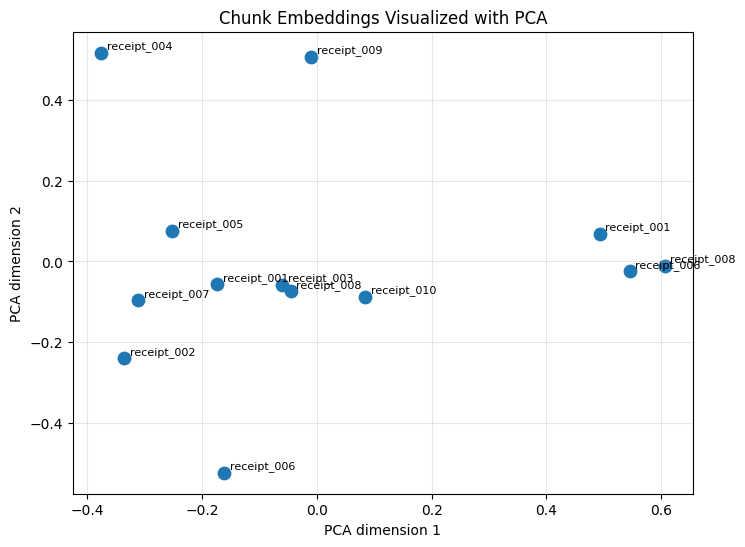

In [26]:
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(chunk_embeddings)

viz_df = chunks_df.copy()
viz_df["x"] = emb_2d[:, 0]
viz_df["y"] = emb_2d[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(viz_df["x"], viz_df["y"], s=80)

for _, row in viz_df.iterrows():
    plt.text(row["x"] + 0.01, row["y"] + 0.01, row["receipt_id"], fontsize=8)

plt.title("Chunk Embeddings Visualized with PCA")
plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.grid(alpha=0.3)
plt.show()


## 9. Retrieval with Cosine Similarity

Before using FAISS, we implement retrieval directly with cosine similarity. This makes the retrieval step transparent.


In [27]:
def retrieve_with_cosine(
    query: str,
    chunks_df: pd.DataFrame,
    chunk_embeddings: np.ndarray,
    model: SentenceTransformer,
    top_k: int = 3,
) -> pd.DataFrame:
    query_embedding = model.encode([query], convert_to_numpy=True)
    scores = cosine_similarity(query_embedding, chunk_embeddings)[0]

    result = chunks_df.copy()
    result["score"] = scores

    result = result.sort_values("score", ascending=False)
    return result[["receipt_id", "chunk_id", "score", "chunk_text"]].head(top_k)


query = "What is the total amount?"
retrieve_with_cosine(query, chunks_df, chunk_embeddings, embedding_model, top_k=5)


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


,receipt_id,chunk_id,score,chunk_text
10,receipt_008,1,0.485525,\nFinal Total EUR 134.99\nCard Payment
1,receipt_001,1,0.464229,Card\nTOTAL EUR 18.50\nThank you for your visit
7,receipt_006,1,0.427962,ro\nTotal paid: 279.00 EUR\nPayment: Mastercard
12,receipt_010,0,0.387921,EDEKA Center\nReceipt No. ED-7400\nDate: 2024-...
5,receipt_005,0,0.356096,LIDL Hamburg\nReceipt ID: LD-9021\nDate: 2024-...


## 10. Build a FAISS Vector Index

FAISS provides efficient nearest-neighbor search.

Important:

> FAISS does not create embeddings. It only indexes vectors and searches over them.

We normalize embeddings so that L2 distance behaves similarly to cosine similarity.


In [28]:
def normalize_vectors(vectors: np.ndarray) -> np.ndarray:
    return vectors / np.linalg.norm(vectors, axis=1, keepdims=True)


normalized_embeddings = normalize_vectors(chunk_embeddings)

if FAISS_AVAILABLE:
    embedding_dim = normalized_embeddings.shape[1]
    index = faiss.IndexFlatL2(embedding_dim)
    index.add(normalized_embeddings.astype("float32"))
    print("FAISS index created.")
    print("Number of indexed vectors:", index.ntotal)
else:
    warnings.warn("FAISS is not available. The notebook will use cosine similarity fallback.")


/var/folders/b2/7y5h0dyx0xg7zxn4_kc28nbh0000gn/T/ipykernel_16364/684897294.py:14: UserWarning: FAISS is not available. The notebook will use cosine similarity fallback.
  warnings.warn("FAISS is not available. The notebook will use cosine similarity fallback.")


In [29]:
def retrieve(
    query: str,
    top_k: int = 3,
    use_faiss: bool = True,
) -> pd.DataFrame:
    query_embedding = embedding_model.encode([query], convert_to_numpy=True)
    query_embedding = normalize_vectors(query_embedding)

    if use_faiss and FAISS_AVAILABLE:
        distances, indices = index.search(query_embedding.astype("float32"), top_k)

        rows = []
        for rank, idx in enumerate(indices[0], start=1):
            row = chunks_df.iloc[idx].to_dict()
            row["rank"] = rank
            row["distance"] = float(distances[0][rank - 1])
            rows.append(row)

        result = pd.DataFrame(rows)
        return result[["rank", "receipt_id", "chunk_id", "distance", "chunk_text"]]

    else:
        result = retrieve_with_cosine(
            query,
            chunks_df,
            chunk_embeddings,
            embedding_model,
            top_k=top_k,
        )
        result.insert(0, "rank", range(1, len(result) + 1))
        return result


retrieve("What is the invoice number?", top_k=5)


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


,rank,receipt_id,chunk_id,score,chunk_text
0,1,receipt_001,0,0.493906,STARBUCKS HAMBURG\nMönckebergstraße 7\nInvoice...
3,2,receipt_003,0,0.478815,IKEA Hamburg Moorfleet\nTax Invoice: IK-2230\n...
9,3,receipt_008,0,0.420097,Saturn Hamburg City\nInvoice Number ST-5512\nD...
12,4,receipt_010,0,0.382181,EDEKA Center\nReceipt No. ED-7400\nDate: 2024-...
2,5,receipt_002,0,0.325726,MediaMarkt Hamburg\nReceipt MM-8891\nDate 2024...


## 11. Try Different Queries

The retriever should return chunks that contain or imply the answer. Try different field-specific questions.


In [30]:
queries = [
    "What is the invoice number?",
    "What is the receipt date?",
    "What is the total amount?",
    "Which payment method was used?",
    "Who is the merchant?",
]

for q in queries:
    print("=" * 80)
    print("Query:", q)
    display(retrieve(q, top_k=3))


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Query: What is the invoice number?


,rank,receipt_id,chunk_id,score,chunk_text
0,1,receipt_001,0,0.493906,STARBUCKS HAMBURG\nMönckebergstraße 7\nInvoice...
3,2,receipt_003,0,0.478815,IKEA Hamburg Moorfleet\nTax Invoice: IK-2230\n...
9,3,receipt_008,0,0.420097,Saturn Hamburg City\nInvoice Number ST-5512\nD...


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Query: What is the receipt date?


...

/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


,rank,receipt_id,chunk_id,score,chunk_text
10,1,receipt_008,1,0.413061,\nFinal Total EUR 134.99\nCard Payment
7,2,receipt_006,1,0.392623,ro\nTotal paid: 279.00 EUR\nPayment: Mastercard
12,3,receipt_010,0,0.322571,EDEKA Center\nReceipt No. ED-7400\nDate: 2024-...


Query: Who is the merchant?


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


,rank,receipt_id,chunk_id,score,chunk_text
2,1,receipt_002,0,0.255216,MediaMarkt Hamburg\nReceipt MM-8891\nDate 2024...
7,2,receipt_006,1,0.250965,ro\nTotal paid: 279.00 EUR\nPayment: Mastercard
12,3,receipt_010,0,0.247471,EDEKA Center\nReceipt No. ED-7400\nDate: 2024-...


## 12. Top-k Experiment

The number of retrieved chunks changes the prompt.

- `top_k=1`: focused but may miss the answer
- `top_k=5`: more context but more noise


In [31]:
query = "What is the total amount?"

for k in [1, 3, 5]:
    print("=" * 80)
    print("Top-k:", k)
    display(retrieve(query, top_k=k))


Top-k: 1


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


,rank,receipt_id,chunk_id,score,chunk_text
10,1,receipt_008,1,0.485525,\nFinal Total EUR 134.99\nCard Payment


Top-k: 3


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


,rank,receipt_id,chunk_id,score,chunk_text
10,1,receipt_008,1,0.485525,\nFinal Total EUR 134.99\nCard Payment
1,2,receipt_001,1,0.464229,Card\nTOTAL EUR 18.50\nThank you for your visit
7,3,receipt_006,1,0.427962,ro\nTotal paid: 279.00 EUR\nPayment: Mastercard


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Top-k: 5


,rank,receipt_id,chunk_id,score,chunk_text
10,1,receipt_008,1,0.485525,\nFinal Total EUR 134.99\nCard Payment
1,2,receipt_001,1,0.464229,Card\nTOTAL EUR 18.50\nThank you for your visit
7,3,receipt_006,1,0.427962,ro\nTotal paid: 279.00 EUR\nPayment: Mastercard
12,4,receipt_010,0,0.387921,EDEKA Center\nReceipt No. ED-7400\nDate: 2024-...
5,5,receipt_005,0,0.356096,LIDL Hamburg\nReceipt ID: LD-9021\nDate: 2024-...


## 13. Prompt Construction

RAG changes the prompt from:

```text
Question → LLM
```

to:

```text
Retrieved Context + Question → LLM
```

The retrieved context grounds the model in the document.


In [32]:
def build_context(retrieved_df: pd.DataFrame) -> str:
    context_parts = []

    for _, row in retrieved_df.iterrows():
        context_parts.append(
            f"[receipt_id={row['receipt_id']}, chunk_id={row['chunk_id']}]\n"
            f"{row['chunk_text']}"
        )

    return "\n\n".join(context_parts)


def build_extraction_prompt(question: str, context: str) -> str:
    return f"""
You are an information extraction system.

Use ONLY the provided context.
If the answer is not present in the context, return null.

Context:
{context}

Question:
{question}

Return the answer only.
""".strip()


retrieved_df = retrieve("What is the total amount?", top_k=3)
context = build_context(retrieved_df)
prompt = build_extraction_prompt("What is the total amount?", context)

print(prompt)


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


You are an information extraction system.

Use ONLY the provided context.
If the answer is not present in the context, return null.

Context:
[receipt_id=receipt_008, chunk_id=1]

Final Total EUR 134.99
Card Payment

[receipt_id=receipt_001, chunk_id=1]
 Card
TOTAL EUR 18.50
Thank you for your visit

[receipt_id=receipt_006, chunk_id=1]
ro
Total paid: 279.00 EUR
Payment: Mastercard

Question:
What is the total amount?

Return the answer only.


## 14. Structured Extraction Prompt

For IE, we usually want structured output instead of free text. We can ask the model to return JSON.


In [33]:
def build_json_extraction_prompt(context: str) -> str:
    return f"""
You are an information extraction system.

Use ONLY the provided context.
Extract the following fields:

- merchant
- invoice
- date
- total
- payment_method

Return valid JSON only, using exactly this schema:

{{
  "merchant": "...",
  "invoice": "...",
  "date": "...",
  "total": "...",
  "payment_method": "..."
}}

If a field is not present in the context, use null.

Context:
{context}
""".strip()


json_prompt = build_json_extraction_prompt(context)
print(json_prompt)


You are an information extraction system.

Use ONLY the provided context.
Extract the following fields:

- merchant
- invoice
- date
- total
- payment_method

Return valid JSON only, using exactly this schema:

{
  "merchant": "...",
  "invoice": "...",
  "date": "...",
  "total": "...",
  "payment_method": "..."
}

If a field is not present in the context, use null.

Context:
[receipt_id=receipt_008, chunk_id=1]

Final Total EUR 134.99
Card Payment

[receipt_id=receipt_001, chunk_id=1]
 Card
TOTAL EUR 18.50
Thank you for your visit

[receipt_id=receipt_006, chunk_id=1]
ro
Total paid: 279.00 EUR
Payment: Mastercard


## 15. Optional LLM Call

In class, this cell may depend on whether you have access to an OpenAI-compatible API.

To keep the notebook runnable for everyone, the actual API call is commented out. You can replace the model name and client configuration according to your environment.


In [34]:
# Optional example:
#
# from openai import OpenAI
#
# client = OpenAI(api_key="YOUR_API_KEY")
#
# response = client.chat.completions.create(
#     model="gpt-4.1-mini",
#     messages=[{"role": "user", "content": json_prompt}],
# )
#
# print(response.choices[0].message.content)


## 16. Simulated LLM for Classroom Execution

To make the notebook fully executable without an API key, we use a small rule-based function that behaves like a structured extractor.

This is **not the main point of RAG**. It only lets us test the pipeline end-to-end without external dependencies.

In a real system, this step would be done by an LLM.


In [35]:
def simulated_llm_extract(context: str) -> str:
    """A simple regex-based extractor used only for classroom execution."""
    merchant_patterns = [
        r"^(STARBUCKS HAMBURG)",
        r"^(MediaMarkt Hamburg)",
        r"^(IKEA Hamburg Moorfleet)",
        r"^(REWE Markt GmbH)",
        r"^(LIDL Hamburg)",
        r"^(APPLE STORE Jungfernstieg)",
        r"^(H&M Hamburg)",
        r"^(Saturn Hamburg City)",
        r"^(dm-drogerie markt)",
        r"^(EDEKA Center)",
    ]

    merchant = None
    for pattern in merchant_patterns:
        match = re.search(pattern, context, flags=re.MULTILINE)
        if match:
            merchant = match.group(1)
            break

    invoice = None
    invoice_match = re.search(
        r"(?:Invoice No:|Receipt|Tax Invoice:|Bon Nr\.|Receipt ID:|Invoice:|Receipt No\.|Beleg-Nr:|Invoice Number)\s*([A-Z0-9\-]+)",
        context,
    )
    if invoice_match:
        invoice = invoice_match.group(1)

    date = None
    date_match = re.search(r"\d{4}-\d{2}-\d{2}", context)
    if date_match:
        date = date_match.group(0)

    total = None
    total_match = re.search(
        r"(?:TOTAL EUR|Grand Total:|Amount Due|SUMME|Total Amount:|Total paid:|Amount:|Final Total EUR|Gesamtbetrag|Total:)\s*([0-9]+\.[0-9]{2})\s*(EUR)?",
        context,
    )
    if total_match:
        amount = total_match.group(1)
        currency = total_match.group(2) or "EUR"
        total = f"{amount} {currency}"

    payment_method = None
    payment_match = re.search(
        r"(?:Payment:|Paid by|Payment Method:|Zahlung:|Paid with|Zahlart:)\s*([A-Za-zÄÖÜäöüß\-\s]+)",
        context,
    )
    if payment_match:
        payment_method = payment_match.group(1).strip()
    elif "Card Payment" in context:
        payment_method = "Card Payment"

    return json.dumps(
        {
            "merchant": merchant,
            "invoice": invoice,
            "date": date,
            "total": total,
            "payment_method": payment_method,
        },
        ensure_ascii=False,
    )


simulated_response = simulated_llm_extract(context)
simulated_response


'{"merchant": null, "invoice": null, "date": null, "total": "134.99 EUR", "payment_method": "Mastercard"}'

## 17. Validate Structured Output with Pydantic

Structured generation is useful, but we still need validation. Pydantic allows us to check whether the model output follows the expected schema.


In [36]:
if not PYDANTIC_AVAILABLE:
    raise ImportError("pydantic is not installed. Run: pip install pydantic")


class ReceiptExtraction(BaseModel):
    merchant: Optional[str] = Field(default=None)
    invoice: Optional[str] = Field(default=None)
    date: Optional[str] = Field(default=None)
    total: Optional[str] = Field(default=None)
    payment_method: Optional[str] = Field(default=None)


parsed = json.loads(simulated_response)
validated = ReceiptExtraction(**parsed)
validated


ReceiptExtraction(merchant=None, invoice=None, date=None, total='134.99 EUR', payment_method='Mastercard')

## 18. End-to-End RAG Function

Now we combine the steps:

1. query
2. retrieve top-k chunks
3. build context
4. build prompt
5. extract JSON
6. validate output


In [37]:
def pydantic_to_dict(model_obj):
    """Compatibility helper for Pydantic v1 and v2."""
    if hasattr(model_obj, "model_dump"):
        return model_obj.model_dump()
    return model_obj.dict()


def rag_extract(receipt_id: str, top_k: int = 3) -> Dict:
    """Run a simple RAG extraction for one receipt.

    For teaching purposes, we query using the receipt id to retrieve chunks belonging
    to that receipt. In real applications, the query might be a user question or
    an extraction instruction.
    """
    query = f"Extract merchant invoice date total payment method for {receipt_id}"

    retrieved = retrieve(query, top_k=top_k)

    # A simple metadata filter can be useful when the document id is known.
    # This mirrors real RAG systems that use metadata filtering.
    retrieved_same_doc = retrieved[retrieved["receipt_id"] == receipt_id]

    if len(retrieved_same_doc) == 0:
        retrieved_same_doc = retrieved

    context = build_context(retrieved_same_doc)
    response = simulated_llm_extract(context)

    try:
        parsed = json.loads(response)
        validated = pydantic_to_dict(ReceiptExtraction(**parsed))
    except Exception as e:
        validated = {
            "merchant": None,
            "invoice": None,
            "date": None,
            "total": None,
            "payment_method": None,
            "error": str(e),
        }

    return {
        "receipt_id": receipt_id,
        "retrieved_context": context,
        "prediction": validated,
    }


output = rag_extract("receipt_001", top_k=5)
output["prediction"]


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


{'merchant': 'STARBUCKS HAMBURG',
 'invoice': 'INV-1001',
 'date': '2024-03-18',
 'total': '18.50 EUR',
 'payment_method': 'Credit Card\nTOTAL EUR'}

## 19. Evaluation

For IE, we can evaluate field-level correctness.

Here we use exact string match. In real systems, evaluation may need normalization:

- lowercasing
- date normalization
- currency normalization
- fuzzy matching for merchant names


In [38]:
def normalize_value(value):
    if value is None:
        return None
    return str(value).strip().lower()


def evaluate_prediction(prediction: Dict, ground_truth: Dict, fields: List[str]) -> Dict:
    result = {}

    for field in fields:
        pred = normalize_value(prediction.get(field))
        gold = normalize_value(ground_truth.get(field))
        result[field] = pred == gold

    return result


fields = ["merchant", "invoice", "date", "total", "payment_method"]

receipt = receipts[0]
prediction = rag_extract(receipt["id"], top_k=5)["prediction"]

evaluate_prediction(prediction, receipt, fields)


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


{'merchant': True,
 'invoice': True,
 'date': True,
 'total': True,
 'payment_method': False}

In [39]:
eval_rows = []

for receipt in receipts:
    result = rag_extract(receipt["id"], top_k=5)
    prediction = result["prediction"]
    field_scores = evaluate_prediction(prediction, receipt, fields)

    row = {"receipt_id": receipt["id"]}
    row.update(field_scores)
    eval_rows.append(row)

eval_df = pd.DataFrame(eval_rows)
eval_df


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*

,receipt_id,merchant,invoice,date,total,payment_method
0,receipt_001,True,True,True,True,False
1,receipt_002,False,False,False,False,False
2,receipt_003,True,True,True,True,False
3,receipt_004,False,False,False,False,False
4,receipt_005,True,False,True,True,True
5,receipt_006,False,False,False,False,False
6,receipt_007,True,False,True,True,True
7,receipt_008,False,False,False,False,False
8,receipt_009,False,False,False,False,False
9,receipt_010,True,False,True,True,True


In [40]:
field_accuracy = eval_df[fields].mean().sort_values(ascending=False)
field_accuracy


merchant          0.5
date              0.5
total             0.5
payment_method    0.3
invoice           0.2
dtype: float64

## 20. Error Analysis

A RAG system can fail in different places:

1. **Retrieval failure**  
   The relevant chunk was not retrieved.

2. **Generation failure**  
   The correct chunk was retrieved, but the LLM extracted the wrong value.

3. **Validation failure**  
   The model output was not valid JSON or did not match the expected schema.

Error analysis helps us locate the weak part of the pipeline.


In [41]:
for receipt in receipts:
    result = rag_extract(receipt["id"], top_k=2)
    prediction = result["prediction"]
    scores = evaluate_prediction(prediction, receipt, fields)

    if not all(scores.values()):
        print("=" * 80)
        print("Receipt:", receipt["id"])
        print("Prediction:", prediction)
        print("Ground truth:", {f: receipt[f] for f in fields})
        print("Scores:", scores)
        print("Retrieved context:")
        print(result["retrieved_context"])


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*

Receipt: receipt_001
Prediction: {'merchant': 'IKEA Hamburg Moorfleet', 'invoice': 'IK-2230', 'date': '2024-04-02', 'total': '212.45 EUR', 'payment_method': 'Debit Card\nAmount Due'}
Ground truth: {'merchant': 'STARBUCKS HAMBURG', 'invoice': 'INV-1001', 'date': '2024-03-18', 'total': '18.50 EUR', 'payment_method': 'Credit Card'}
Scores: {'merchant': False, 'invoice': False, 'date': False, 'total': False, 'payment_method': False}
Retrieved context:
[receipt_id=receipt_003, chunk_id=0]
IKEA Hamburg Moorfleet
Tax Invoice: IK-2230
Purchase Date: 2024-04-02
Payment Method: Debit Card
Amount Due 212.45 EUR

[receipt_id=receipt_010, chunk_id=0]
EDEKA Center
Receipt No. ED-7400
Date: 2024-02-28
Groceries and household items
Total: 102.34 EUR
Paid by Credit Card
Receipt: receipt_002
Prediction: {'merchant': 'IKEA Hamburg Moorfleet', 'invoice': 'IK-2230', 'date': '2024-04-02', 'total': '212.45 EUR', 'payment_method': 'Debit Card\nAmount Due'}
Ground truth: {'merchant': 'MediaMarkt Hamburg', 'inv

/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


## 21. Failure Case: Unanswerable Question

RAG does not magically create missing information.

If the answer is not present in the retrieved context, the system should return `null`.

A bad system may hallucinate.


In [42]:
bad_query = "What is the customer's phone number?"
bad_retrieval = retrieve(bad_query, top_k=3)
bad_context = build_context(bad_retrieval)

print("Retrieved context:")
print(bad_context)

print("\nPrompt:")
print(build_extraction_prompt(bad_query, bad_context))


/opt/anaconda3/envs/exr/lib/python3.10/site-packages/torch/nn/modules/module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Retrieved context:
[receipt_id=receipt_002, chunk_id=0]
MediaMarkt Hamburg
Receipt MM-8891
Date 2024-05-11
Item: Bluetooth Speaker
Paid by VISA
Grand Total: 579.99 EUR

[receipt_id=receipt_010, chunk_id=0]
EDEKA Center
Receipt No. ED-7400
Date: 2024-02-28
Groceries and household items
Total: 102.34 EUR
Paid by Credit Card

[receipt_id=receipt_008, chunk_id=0]
Saturn Hamburg City
Invoice Number ST-5512
Date of purchase: 2024-05-28
Laptop accessories
Final Total EUR 134.99
Card P

Prompt:
You are an information extraction system.

Use ONLY the provided context.
If the answer is not present in the context, return null.

Context:
[receipt_id=receipt_002, chunk_id=0]
MediaMarkt Hamburg
Receipt MM-8891
Date 2024-05-11
Item: Bluetooth Speaker
Paid by VISA
Grand Total: 579.99 EUR

[receipt_id=receipt_010, chunk_id=0]
EDEKA Center
Receipt No. ED-7400
Date: 2024-02-28
Groceries and household items
Total: 102.34 EUR
Paid by Credit Card

[receipt_id=receipt_008, chunk_id=0]
Saturn Hamburg City
Inv

## 22. Exercise 1 — Chunk Size

Rebuild the chunk dataframe with different chunk sizes:

- 60
- 120
- 240

For each setting:

1. count the number of chunks
2. run retrieval for `"What is the total amount?"`
3. inspect whether the retrieved chunks contain the answer


In [43]:
# TODO: Try different chunk sizes here.

# for size in [60, 120, 240]:
#     temp_chunks_df = build_chunks(receipts, chunk_size=size, overlap=30)
#     print(size, len(temp_chunks_df))


## 23. Exercise 2 — Top-k

Compare:

- top_k = 1
- top_k = 3
- top_k = 5

Question:

> Does retrieving more chunks always improve extraction?


In [44]:
# TODO: Compare different top-k values.

# for k in [1, 3, 5]:
#     display(retrieve("What is the payment method?", top_k=k))


## 24. Exercise 3 — Add a New Field

Extend the extraction schema with one additional field:

- address
- cashier
- product
- store location

Then update:

1. the prompt
2. the Pydantic model
3. the evaluation code


In [45]:
# TODO:
# Add a new field to ReceiptExtraction.
# Then update the prompt and evaluation.


## 25. Exercise 4 — Retrieval vs Generation

Pick one incorrect prediction or create one manually.

Decide whether the error is caused by:

- retrieval failure
- extraction/generation failure
- schema validation failure

Write your explanation in a markdown cell.


## Reflection Questions

1. Why do we use retrieval before generation?
2. Why is chunking important?
3. What is the role of the embedding model?
4. What does FAISS do, and what does it not do?
5. Why do we add retrieved context to the prompt?
6. What happens if retrieval returns the wrong chunks?
7. Why is structured JSON useful for Information Extraction?
8. Why do we still need validation after LLM generation?
9. How would you improve this pipeline for real SROIE documents?


## Summary

In this notebook, we built a small but complete RAG pipeline for Information Extraction.

We covered:

- OCR-like receipt data
- chunking
- embeddings
- semantic retrieval
- FAISS indexing
- prompt construction
- structured JSON extraction
- Pydantic validation
- field-level evaluation
- error analysis

Main takeaway:

> RAG is not just an LLM call.  
> It is a pipeline. Retrieval quality, chunking, prompting, validation, and evaluation all matter.
